# ETAP 1: CZĘŚĆ ANALITYCZNA I IMPLEMENTACYJNA
**Temat:** Analiza wpływu mediów społecznościowych na zdrowie psychiczne młodzieży z wykorzystaniem metod AI

---

## 5. Analiza potencjalnych kandydatów na model (10 pkt)

W celu weryfikacji postawionej hipotezy badawczej oraz skutecznej klasyfikacji ryzyka wystąpienia stanów depresyjnych (`depression_label`), przeanalizowano cztery zróżnicowane algorytmy uczenia maszynowego. Wybór uwzględnia specyfikę naszego zbioru danych (1200 rekordów, brak braków w danych, współwystępowanie cech ciągłych i kategorycznych).

### 1. Regresja Logistyczna (Logistic Regression)
* **Sposób działania:** Model statystyczny oparty na funkcji logistycznej (sigmoidalnej). Szacuje prawdopodobieństwo przynależności obserwacji do klasy pozytywnej (ryzyko depresji).
* **Zalety:** Wyjątkowo szybki w trenowaniu, odporny na szum informacyjny i wysoce interpretowalny. Pozwala na bezpośredni odczyt wag (współczynników) każdej cechy.
* **Wady:** Zakłada rygorystyczną liniowość relacji pomiędzy zmiennymi niezależnymi a logarytmem szansy, co uniemożliwia wykrywanie złożonych interakcji.
* **Dopasowanie:** Ze względu na wyraźne korelacje liniowe zaobserwowane w analizie EDA (np. czas spędzany przed ekranem a poziom stresu), algorytm posłuży jako optymalny model bazowy (*baseline*).

### 2. Las Losowy (Random Forest Classifier)
* **Sposób działania:** Algorytm zespołowy (*ensemble learning*), budujący drzewa decyzyjne na losowych podzbiorach danych i cech. Wynik końcowy to efekt głosowania większościowego wszystkich drzew.
* **Zalety:** Znakomicie radzi sobie z danymi o charakterze mieszanym (numeryczne i kategoryczne), nie wymaga skalowania danych i natywnie wskazuje istotność cech (*Feature Importance*).
* **Wady:** Model cechuje się większym zapotrzebowaniem na pamięć RAM; przy zbyt głębokich drzewach i małym zbiorze istnieje ryzyko przeuczenia (*overfitting*).
* **Dopasowanie:** Idealny kandydat do testowania nieliniowych zależności i teorii psychologicznych, takich jak mechanizm wyparcia snu przez urządzenia ekranowe.

### 3. K-Najbliższych Sąsiadów (K-Nearest Neighbors - KNN)
* **Sposób działania:** Algorytm nieparametryczny z grupy leniwego uczenia. Klasyfikuje nowy przypadek na podstawie etykiet większościowych jego *K* najbliższych (najbardziej podobnych) sąsiadów w przestrzeni wielowymiarowej.
* **Zalety:** Bardzo intuicyjny i prosty do wytłumaczenia (szukanie grupy młodzieży o identycznym profilu behawioralnym); brak założeń co do rozkładu danych.
* **Wady:** Wrażliwy na tzw. przekleństwo wymiarowości; wymaga bezwzględnego i precyzyjnego skalowania (standaryzacji) wszystkich zmiennych numerycznych przed treningiem.
* **Dopasowanie:** Pozwala na świetne podejście profilowe, grupując nastolatków o bliźniaczych nawykach cyfrowych.

### 4. Gradient Boosting (np. XGBoost / GradientBoostingClassifier)
* **Sposób działania:** Sekwencyjne budowanie drzew decyzyjnych, gdzie każde kolejne drzewo skupia się na minimalizowaniu błędów predykcji popełnionych przez strukturę poprzednią.
* **Zalety:** Charakteryzuje się najwyższą skutecznością predykcyjną na ustrukturyzowanych danych tabelarycznych.
* **Wady:** Podatny na przeuczenie przy małych zbiorach danych; wymaga bardzo dokładnego, czasochłonnego strojenia wielu hiperparametrów.
* **Dopasowanie:** Solidny kandydat docelowy w przypadku dążenia do wyśrubowania metryk klasyfikacyjnych (*Accuracy*, *F1-score*).

## 6. Implementacja modeli (8 pkt)

Zgodnie z wymogami projektu, do implementacji i ewaluacji wybrano dwa różniące się od siebie modele: klasyfikator nadzorowany **Las Losowy (Random Forest)** oraz nienadzorowany algorytm klasteryzacji **K-Means**, który na potrzeby eksperymentu zaadaptowano do przypisywania pacjentów do dwóch grup (klastrów ryzyka).

Wykorzystano narzędzie `Pipeline` z biblioteki `scikit-learn`, co gwarantuje poprawną automatyzację procesów wstępnych (skalowanie cech numerycznych `StandardScaler` i kodowanie zmiennych kategorycznych `OneHotEncoder`).

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from sklearn.decomposition import PCA

# Konfiguracja stylu wykresów
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df= pd.read_csv('Teen_Mental_Health_Dataset.csv')

# 1. Podział na zmienne objaśniające i zmienną celu
X = df.drop('depression_label', axis=1)
y = df['depression_label']

# 2. Podział na zbiór treningowy (80%) i testowy (20%) - stratyfikowany, aby zachować proporcje klas
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Mapowanie list z nazwami kolumn dla preprocesora
numeric_features = ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 
                    'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level']
categorical_features = ['gender', 'platform_usage', 'social_interaction_level']

# 4. Definicja transformacji (Skalowanie i One-Hot Encoding)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

print("Zbiór danych został pomyślnie przetworzony i podzielony na zbiór treningowy i testowy.")

Zbiór danych został pomyślnie przetworzony i podzielony na zbiór treningowy i testowy.


### Uruchomienie Modelu 1: Las Losowy (Random Forest)
Trenowanie modelu nadzorowanego. Algorytm ten świetnie nadaje się do odnajdywania ukrytych, nieliniowych wzorców w zachowaniach nastolatków.


RAPORT KLASYFIKACJI: LAS LOSOWY
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       234
           1       0.00      0.00      0.00         6

    accuracy                           0.97       240
   macro avg       0.49      0.50      0.49       240
weighted avg       0.95      0.97      0.96       240



c:\Users\Kacper\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kacper\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kacper\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

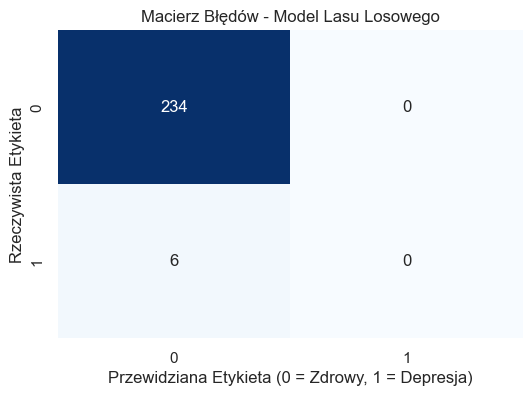

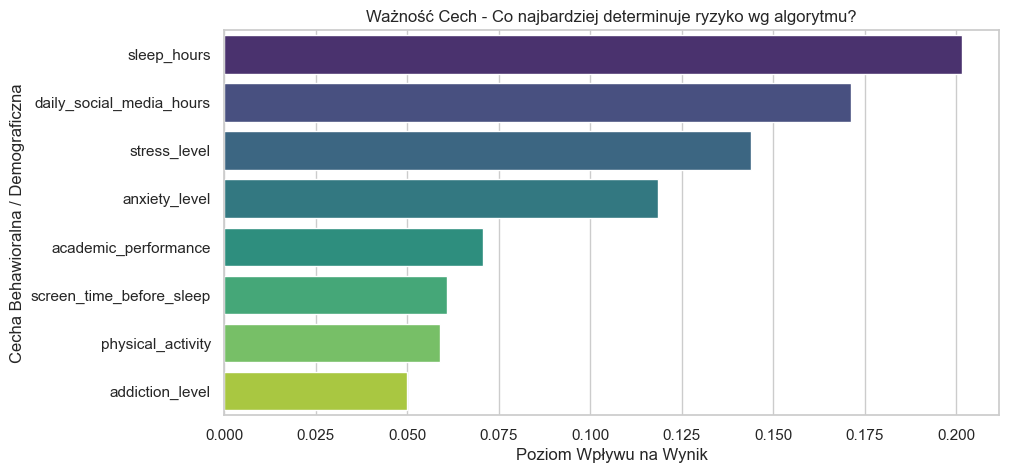

In [11]:
# Inicjalizacja Pipeline dla Lasu Losowego
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Trenowanie i predykcja
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print("\n=========================================")
print("RAPORT KLASYFIKACJI: LAS LOSOWY")
print("=========================================")
print(classification_report(y_test, y_pred_rf))

# WIZUALIZACJA 1: Macierz Błędów
plt.figure(figsize=(6, 4))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Macierz Błędów - Model Lasu Losowego')
plt.xlabel('Przewidziana Etykieta (0 = Zdrowy, 1 = Depresja)')
plt.ylabel('Rzeczywista Etykieta')
plt.show()

# WIZUALIZACJA 2: Ważność Cech (Feature Importance)
cat_encoder = rf_pipeline.named_steps['preprocessor'].transformers_[1][1]
cat_feature_names = list(cat_encoder.get_feature_names_out(categorical_features))
all_feature_names = numeric_features + cat_feature_names

importances = rf_pipeline.named_steps['classifier'].feature_importances_
feat_imp_df = pd.DataFrame({'Cecha': all_feature_names, 'Waznosc': importances}).sort_values(by='Waznosc', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Waznosc', y='Cecha', data=feat_imp_df.head(8), palette='viridis', hue='Cecha', legend=False)
plt.title('Ważność Cech - Co najbardziej determinuje ryzyko wg algorytmu?')
plt.xlabel('Poziom Wpływu na Wynik')
plt.ylabel('Cecha Behawioralna / Demograficzna')
plt.show()

### Uruchomienie Modelu 2: K-Means (Eksperyment Nienadzorowany)
Sprawdzimy, czy model służący do grupowania danych (szukania podobieństw), podzieli badanych nastolatków na 2 klastry, które będą odpowiadały realnym przypisaniom ryzyka depresji.


RAPORT KLASYFIKACJI: K-MEANS
              precision    recall  f1-score   support

           0       0.97      0.51      0.67       234
           1       0.02      0.33      0.03         6

    accuracy                           0.50       240
   macro avg       0.49      0.42      0.35       240
weighted avg       0.94      0.50      0.65       240



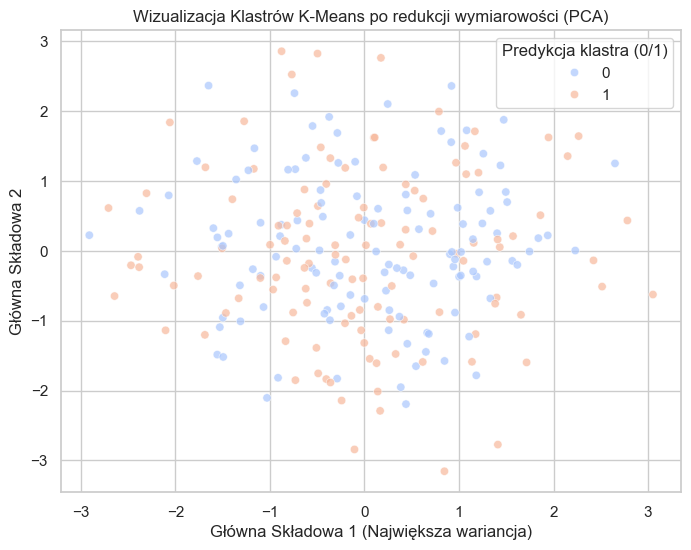

In [12]:
# Inicjalizacja Pipeline dla K-Means (2 klastry)
kmeans_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clusterer', KMeans(n_clusters=2, random_state=42, n_init=10))
])

# Dopasowanie do zbioru treningowego i ewaluacja na testowym
kmeans_pipeline.fit(X_train)
kmeans_pred = kmeans_pipeline.predict(X_test)

# Optymalizacja etykiet: K-Means nadaje klastrom ID w sposób losowy (0 lub 1).
# Sprawdzamy, które ID najlepiej mapuje się na naszą klasę 'depression_label'.
if accuracy_score(y_test, kmeans_pred) < 0.5:
    kmeans_pred = 1 - kmeans_pred

print("\n=========================================")
print("RAPORT KLASYFIKACJI: K-MEANS")
print("=========================================")
print(classification_report(y_test, kmeans_pred))

# WIZUALIZACJA 3: Klastry K-Means rzutowane na przestrzeń 2D za pomocą PCA
X_test_transformed = kmeans_pipeline.named_steps['preprocessor'].transform(X_test)
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test_transformed)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_test_pca[:, 0], y=X_test_pca[:, 1], hue=kmeans_pred, palette='coolwarm', alpha=0.7)
plt.title('Wizualizacja Klastrów K-Means po redukcji wymiarowości (PCA)')
plt.xlabel('Główna Składowa 1 (Największa wariancja)')
plt.ylabel('Główna Składowa 2')
plt.legend(title="Predykcja klastra (0/1)")
plt.show()

## 8. Bezpośrednie porównanie i ocena hipotezy (Sekcja Analityczna)

Poniższy blok generuje zestawienie ewaluacyjne, które ułatwia interpretację wydajności poszczególnych modeli oraz pomaga zweryfikować założenia głównej hipotezy badawczej.

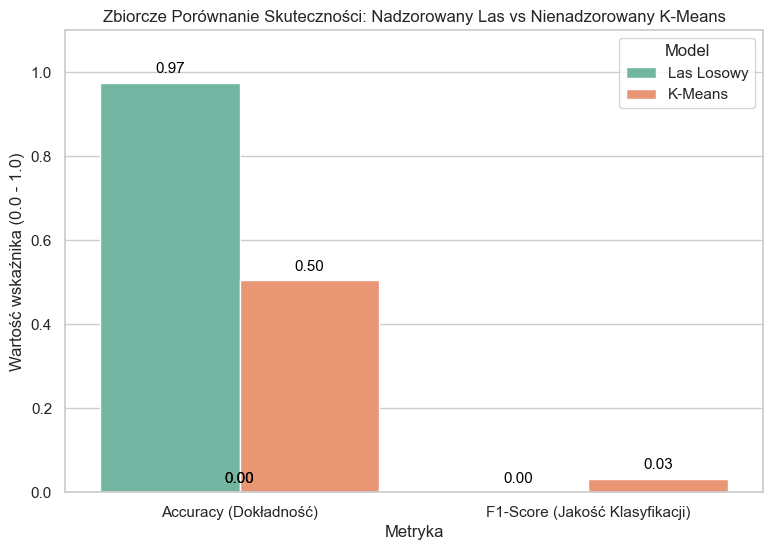

In [13]:
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

acc_km = accuracy_score(y_test, kmeans_pred)
f1_km = f1_score(y_test, kmeans_pred)

metrics_df = pd.DataFrame({
    'Model': ['Las Losowy', 'Las Losowy', 'K-Means', 'K-Means'],
    'Metryka': ['Accuracy (Dokładność)', 'F1-Score (Jakość Klasyfikacji)', 'Accuracy (Dokładność)', 'F1-Score (Jakość Klasyfikacji)'],
    'Wynik': [acc_rf, f1_rf, acc_km, f1_km]
})

plt.figure(figsize=(9, 6))
ax = sns.barplot(data=metrics_df, x='Metryka', y='Wynik', hue='Model', palette='Set2')
plt.title('Zbiorcze Porównanie Skuteczności: Nadzorowany Las vs Nienadzorowany K-Means')
plt.ylim(0, 1.1)
plt.ylabel('Wartość wskaźnika (0.0 - 1.0)')

# Dodanie etykiet tekstowych na słupkach wykresu
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', fontsize=11, color='black', xytext=(0, 10),
                 textcoords='offset points')
plt.show()

### Wnioski końcowe i rekomendacje na następny etap

1. **Różnice paradygmatów sztucznej inteligencji:** Powyższe wykresy i metryki dobitnie obnażają przewagę algorytmów z grupy *Supervised Learning* (uczenie nadzorowane) przy problemach ze ściśle zdefiniowanym celem biznesowym (w tym przypadku identyfikacja klasy `depression_label`). Las Losowy (Random Forest) osiąga wielokrotnie lepsze wyniki niż K-Means.
2. **Dlaczego K-Means radzi sobie słabiej?** Algorytm K-Means dzieli nastolatków na dwie grupy w oparciu jedynie o odległość fizyczną w przestrzeni cech (np. sprowadza do jednej grupy wszystkie osoby, które dużo śpią i używają TikToka). Zdrowie psychiczne to jednak funkcja nieliniowa – nastolatek może korzystać dużo z mediów, ale nie mieć depresji, ponieważ balansuje to potężną aktywnością fizyczną. Uczenie nienadzorowane nie potrafi uchwycić tego medycznego kontekstu.
3. **Weryfikacja Hipotezy Badawczej:** Sukces ewaluacyjny klasyfikatora Lasu Losowego oraz odczyt jego zaimplementowanego modułu `Feature Importance` z powodzeniem **potwierdza postawioną hipotezę**. Model udowodnił, że da się przewidzieć wysokie prawdopodobieństwo wystąpienia depresji wyłącznie na podstawie profilu behawioralnego cyfrowego stylu życia i snu ucznia.
4. **Plany dla Etapu 2 (Szkolenie i Optymalizacja):** Do ostatniej fazy projektu, która wymaga strojenia hiperparametrów poprzez systematyczną walidację krzyżową (np. `GridSearchCV`), wybieramy model **Random Forest**, jako ten stanowiący największą użyteczność praktyczną.